# Powerseed Variation Analysis

This notebook reads the precomputed Hessian, covariance, and soft-mode outputs for `ReducedLogGaussPowerSeed` on the default `MSHT20N3LO-MC-0-2` tables.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("../Fits/powerseed_hessian_analysis_results")
summary = json.loads((RESULTS_DIR / "summary.json").read_text(encoding="utf-8"))
parameter_summary = pd.read_csv(RESULTS_DIR / "parameter_summary.csv")
corr = pd.read_csv(RESULTS_DIR / "correlation_matrix.csv", index_col=0)
top_corr = pd.read_csv(RESULTS_DIR / "top_correlations.csv")
mode_summary = pd.read_csv(RESULTS_DIR / "mode_summary.csv")
soft_modes = pd.read_csv(RESULTS_DIR / "soft_mode_variations_highE.csv")

pd.set_option("display.precision", 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = False

summary

{'model': 'reduced_loggauss_powerseed',
 'fit_name': 'SigGood_reduced_loggauss_powerseed',
 'n_total': 465,
 'chi2dN_total': 0.8262317309161787,
 'chi2_total': 384.1977548760231,
 'highE_mean_absdev_first3': 0.05143435344971727,
 'highE_mean_shortfall_first3': 0.010446309247199869,
 'rel_step': 0.0005,
 'hessian_evals': 163,
 'grad_norm_log10': 0.026657454113397552,
 'hessian_min_eig': 2457.3539622460903,
 'hessian_max_eig': 994765.0687058896}

In [2]:
parameter_summary = parameter_summary.copy()
parameter_summary["abs_value"] = parameter_summary["value"].abs()
parameter_summary["signal_to_sigma"] = parameter_summary["abs_value"] / parameter_summary["sigma_phys"]
parameter_summary.sort_values("frac_uncertainty")[["param", "value", "sigma_phys", "frac_uncertainty", "signal_to_sigma"]]

,param,value,sigma_phys,frac_uncertainty,signal_to_sigma
7,c0,0.079388,0.002654,0.033433,29.910386
6,BNP,1.416279,0.047607,0.033614,29.749190
3,logx0,-4.580855,0.198276,0.043284,23.103374
8,c1,0.022284,0.002130,0.095569,10.463631
0,lambda1,0.543681,0.057541,0.105836,9.448618
4,sigx,0.335366,0.039370,0.117395,8.518280
1,lambda2,0.624789,0.083678,0.133930,7.466594
5,amp,-0.485170,0.105645,0.217748,4.592461
2,lambda4,0.024650,0.015657,0.635160,1.574406


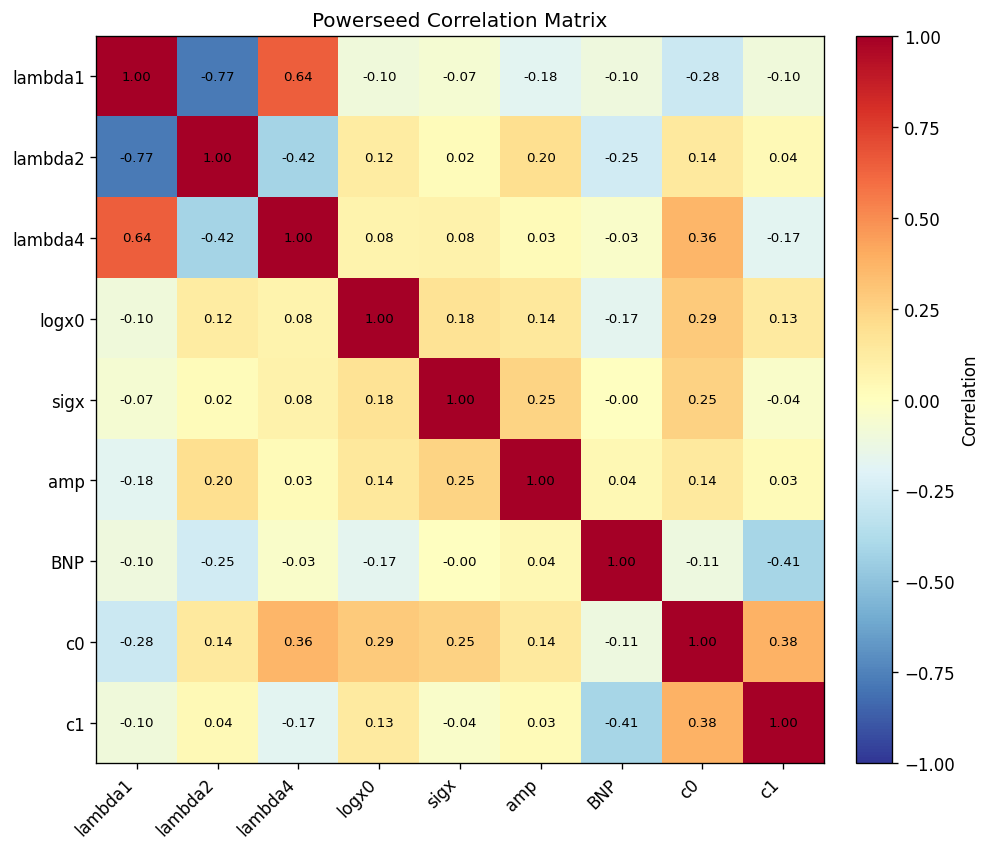

In [3]:
fig, ax = plt.subplots(figsize=(8.2, 7.2))
im = ax.imshow(corr.to_numpy(), vmin=-1.0, vmax=1.0, cmap="RdYlBu_r")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
ax.set_title("Powerseed Correlation Matrix")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Correlation")
fig.tight_layout()

In [4]:
top_corr

,param_i,param_j,corr,abs_corr
0,lambda1,lambda2,-0.774878,0.774878
1,lambda1,lambda4,0.644298,0.644298
2,lambda2,lambda4,-0.419796,0.419796
3,BNP,c1,-0.409051,0.409051
4,c0,c1,0.377402,0.377402
5,lambda4,c0,0.361677,0.361677
6,logx0,c0,0.288691,0.288691
7,lambda1,c0,-0.277083,0.277083
8,sigx,c0,0.253861,0.253861
9,lambda2,BNP,-0.252638,0.252638


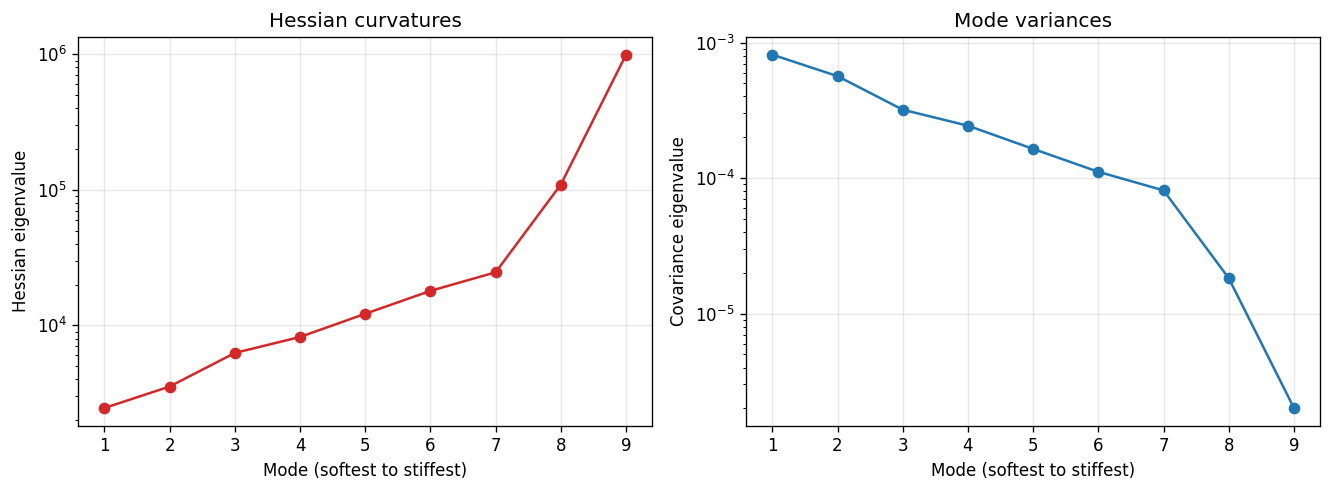

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2))
modes = np.arange(1, len(mode_summary) + 1)

axes[0].semilogy(modes, mode_summary["curvature_eig"], marker="o", color="tab:red")
axes[0].set_xlabel("Mode (softest to stiffest)")
axes[0].set_ylabel("Hessian eigenvalue")
axes[0].set_title("Hessian curvatures")
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(modes, mode_summary["variance_eig_norm"], marker="o", color="tab:blue")
axes[1].set_xlabel("Mode (softest to stiffest)")
axes[1].set_ylabel("Covariance eigenvalue")
axes[1].set_title("Mode variances")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()

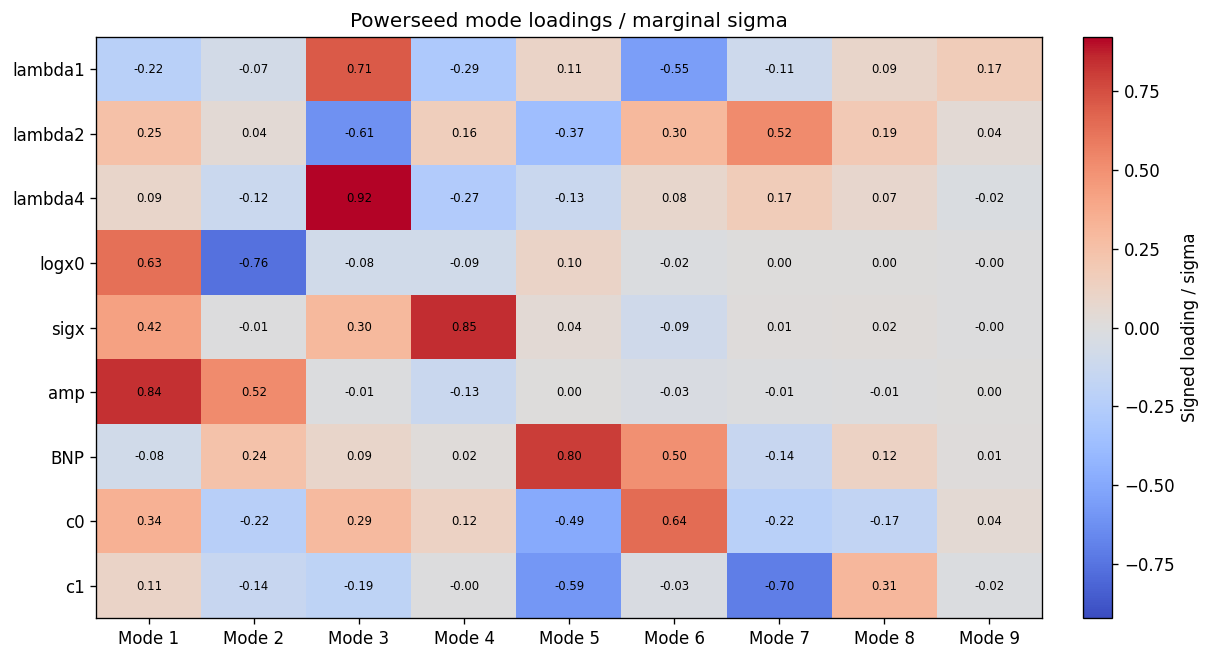

In [6]:
param_names = corr.columns.tolist()
load_cols = [f"{name}_loading_over_sigma" for name in param_names]
load = mode_summary[load_cols].to_numpy(dtype=float).T

fig, ax = plt.subplots(figsize=(10.2, 5.6))
vmax = float(np.max(np.abs(load)))
im = ax.imshow(load, aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(mode_summary)))
ax.set_xticklabels([f"Mode {i}" for i in range(1, len(mode_summary) + 1)])
ax.set_yticks(range(len(param_names)))
ax.set_yticklabels(param_names)
ax.set_title("Powerseed mode loadings / marginal sigma")

for i in range(load.shape[0]):
    for j in range(load.shape[1]):
        ax.text(j, i, f"{load[i, j]:.2f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Signed loading / sigma")
fig.tight_layout()

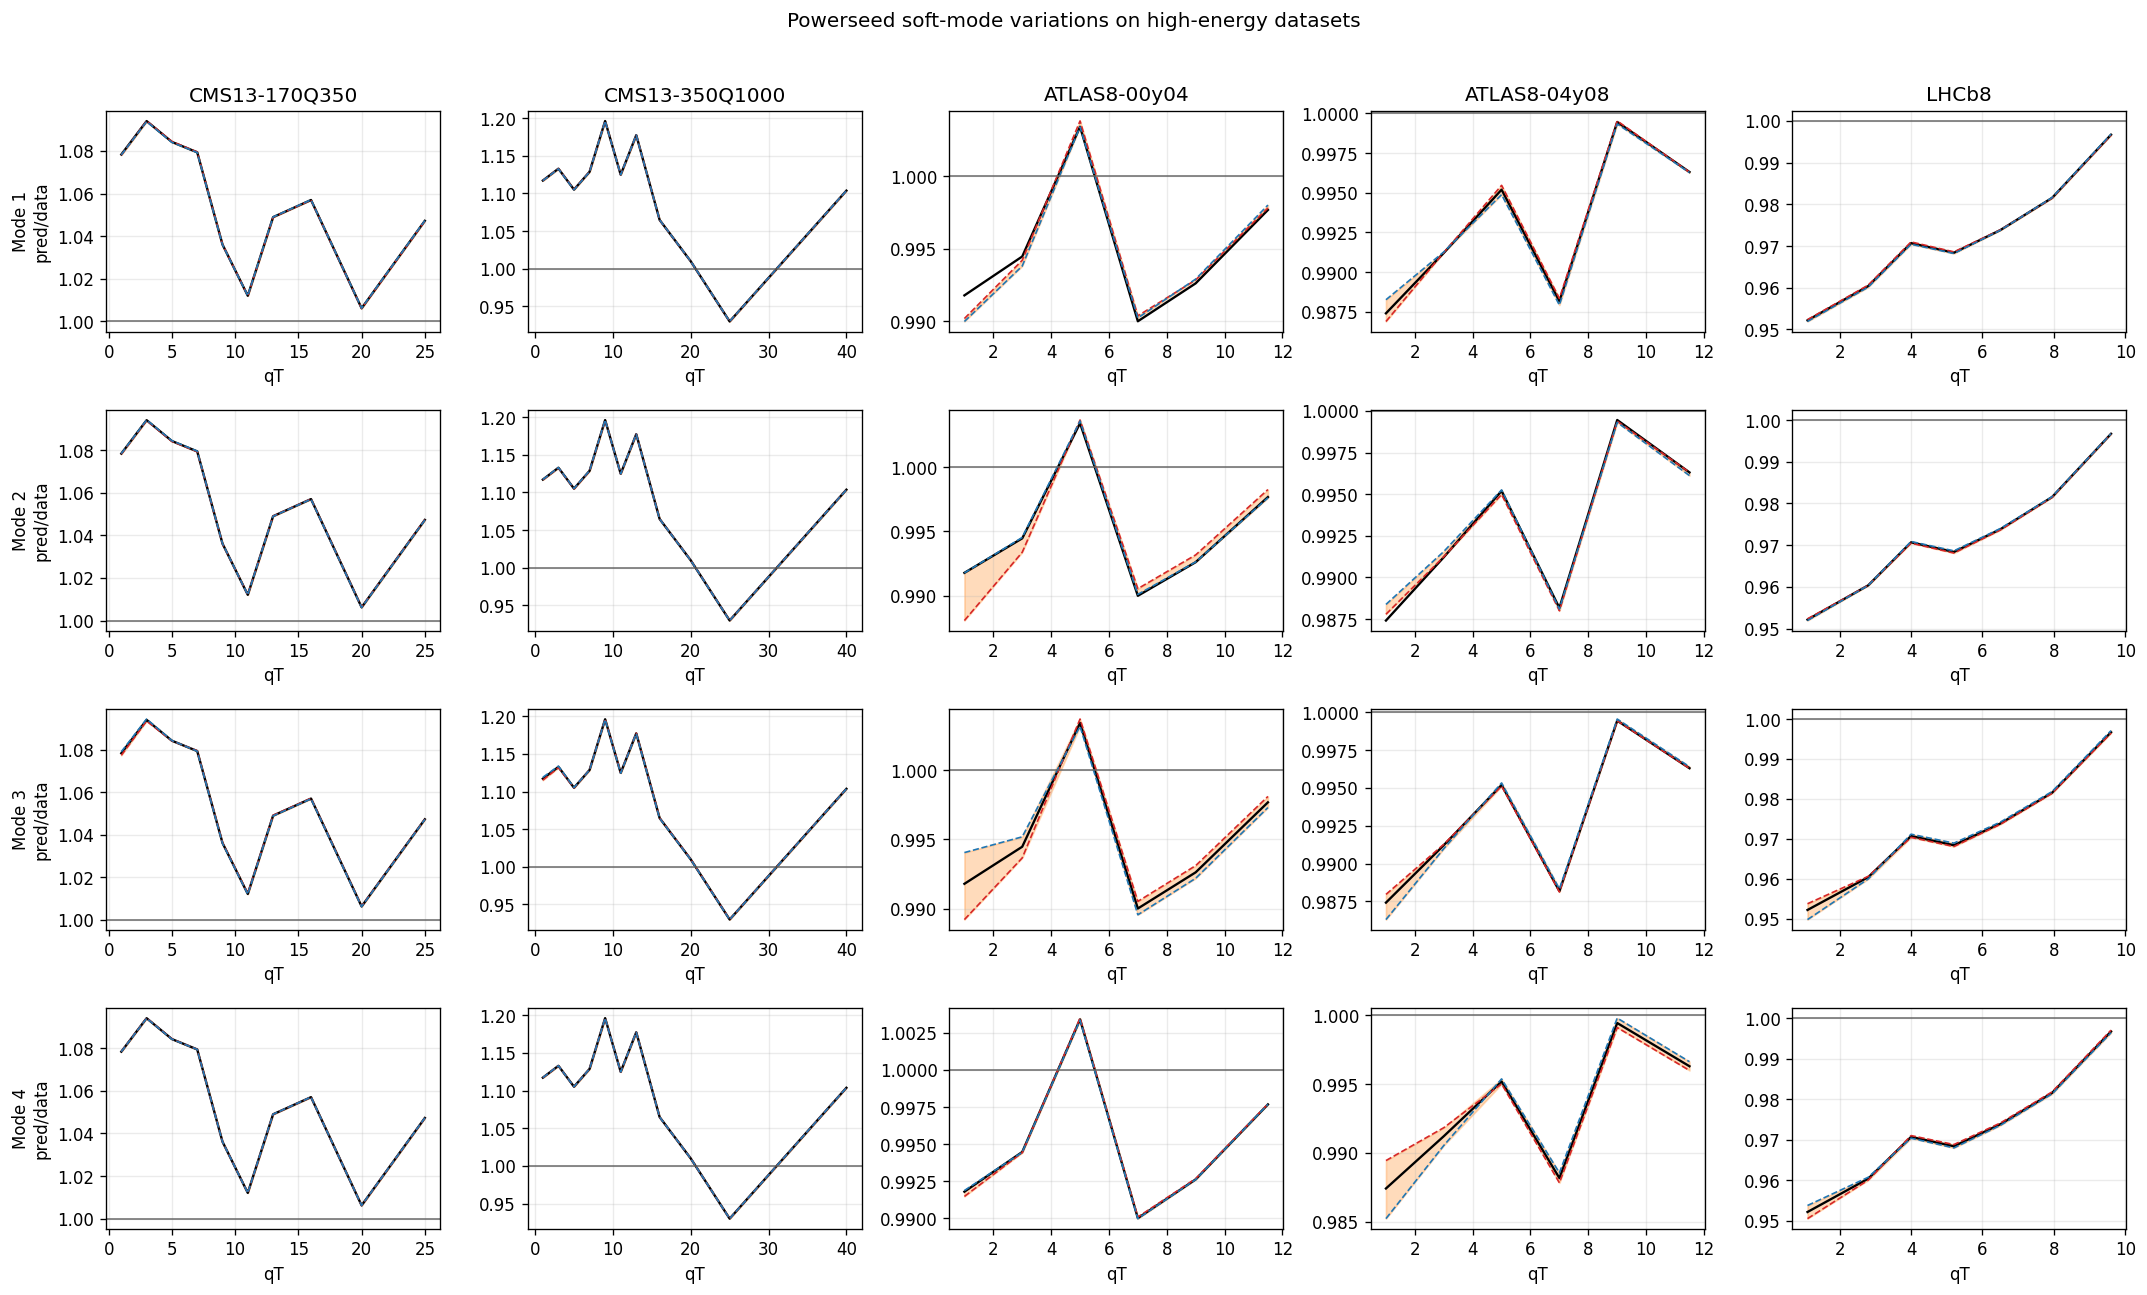

In [7]:
high_energy_files = list(dict.fromkeys(soft_modes["file"].tolist()))
soft_modes["dataset"] = soft_modes["file"].map(lambda x: Path(x).stem)

n_modes = int(soft_modes["mode"].max())
ncols = len(high_energy_files)
fig, axes = plt.subplots(n_modes, ncols, figsize=(3.6 * ncols, 2.7 * n_modes), sharex=False, sharey=False)
axes = np.atleast_2d(axes)

for r in range(n_modes):
    for c, file_name in enumerate(high_energy_files):
        ax = axes[r, c]
        block = soft_modes[(soft_modes["mode"] == r + 1) & (soft_modes["file"] == file_name)]
        block0 = block[block["sign"] == "0"].sort_values("bin_index")
        blockp = block[block["sign"] == "+"].sort_values("bin_index")
        blockm = block[block["sign"] == "-"].sort_values("bin_index")

        qT = block0["qT"].to_numpy(dtype=float)
        y0 = block0["ratio"].to_numpy(dtype=float)
        yp = blockp["ratio"].to_numpy(dtype=float)
        ym = blockm["ratio"].to_numpy(dtype=float)

        ax.fill_between(qT, np.minimum(ym, yp), np.maximum(ym, yp), color="tab:orange", alpha=0.28)
        ax.plot(qT, y0, color="black", linewidth=1.4)
        ax.plot(qT, yp, color="tab:red", linestyle="--", linewidth=1.0)
        ax.plot(qT, ym, color="tab:blue", linestyle="--", linewidth=1.0)
        ax.axhline(1.0, color="0.4", linewidth=0.9)
        ax.grid(True, alpha=0.25)
        if r == 0:
            ax.set_title(Path(file_name).stem)
        if c == 0:
            ax.set_ylabel(f"Mode {r+1}\npred/data")
        ax.set_xlabel("qT")

fig.suptitle("Powerseed soft-mode variations on high-energy datasets", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.98))